<a href="https://colab.research.google.com/github/priscyboatO/titanic-exploratory-data-analysis-PBO/blob/main/Assignment_5_Titanic_EDA_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Name: Priscilla Boatema Otu
#  Assignment 5 - Titanic Exploratory Data Analysis


In [2]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Task 1: Load the Titanic Dataset

In [3]:

# Load the Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (891, 12)



### Insight
The dataset contains passenger-level information such as survival status, passenger class, sex, age, fare, family relationships, cabin, and embarkation point.


## Task 2: Inspect the Data

In [4]:

# Display the first 5 rows
print("First 5 rows:")
display(df.head())

# Display the last 5 rows
print("Last 5 rows:")
display(df.tail())

# Display data types
print("Data types:")
print(df.dtypes)

# Display summary statistics
print("\nSummary statistics:")
display(df.describe())


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Summary statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



### Insight
The dataset contains both numerical and categorical variables. Numerical fields include Age, Fare, SibSp, Parch, Pclass, and Survived.


## Task 3: Clean and Preprocess the Data

In [5]:

# Create a categorical feature for passenger class
pclass_map = {
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
}
df["PclassCategory"] = df["Pclass"].map(pclass_map)

# Create CabinCategory using the first letter of the cabin.
# Missing cabin values are labeled Unknown.
df["CabinCategory"] = df["Cabin"].fillna("Unknown").astype(str).str[0]
df.loc[df["Cabin"].isna(), "CabinCategory"] = "Unknown"

# Check missing values before filling Age
print("Missing Age values before:", df["Age"].isna().sum())

# Fill missing Age values using the mean age
mean_age = df["Age"].mean()
df["Age"] = df["Age"].fillna(mean_age)

print("Missing Age values after:", df["Age"].isna().sum())
print("Mean age used:", round(mean_age, 2))

# Create Family feature
df["Family"] = df["SibSp"] + df["Parch"]

print("\nNew features:")
display(df[["Pclass", "PclassCategory", "Cabin", "CabinCategory", "Age", "Family"]].head())


Missing Age values before: 177
Missing Age values after: 0
Mean age used: 29.7

New features:


,Pclass,PclassCategory,Cabin,CabinCategory,Age,Family
0,3,Third Class,NaN,Unknown,22.0,1
1,1,First Class,C85,C,38.0,1
2,3,Third Class,NaN,Unknown,26.0,0
3,1,First Class,C123,C,35.0,1
4,3,Third Class,NaN,Unknown,35.0,0



### Insight
Missing ages were replaced with the mean age so that the Age column could be used in later analysis without dropping passengers. The Family feature combines siblings/spouses and parents/children travelling with each passenger.


## Task 4: Identify Specific Data Points

In [6]:

# Find passenger(s) with the highest fare
highest_fare = df["Fare"].max()
highest_fare_passengers = df[df["Fare"] == highest_fare]

print("Passenger(s) with the highest fare:")
display(highest_fare_passengers[["Name", "Fare", "Pclass"]])

# Find passenger(s) with the largest family size
largest_family = df["Family"].max()
largest_family_passengers = df[df["Family"] == largest_family]

print("Passenger(s) with the largest family size:")
display(largest_family_passengers[["Name", "Family", "SibSp", "Parch"]])


Passenger(s) with the highest fare:


,Name,Fare,Pclass
258,"Ward, Miss. Anna",512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
737,"Lesurer, Mr. Gustave J",512.3292,1


Passenger(s) with the largest family size:


,Name,Family,SibSp,Parch
159,"Sage, Master. Thomas Henry",10,8,2
180,"Sage, Miss. Constance Gladys",10,8,2
201,"Sage, Mr. Frederick",10,8,2
324,"Sage, Mr. George John Jr",10,8,2
792,"Sage, Miss. Stella Anna",10,8,2
846,"Sage, Mr. Douglas Bullen",10,8,2
863,"Sage, Miss. Dorothy Edith ""Dolly""",10,8,2



### Insight
Using maximum values makes it easy to identify passengers at the extremes of the Fare and Family variables.


## Task 5: Pandas Series and DataFrame Functionalities

In [7]:

# Create a Pandas Series of passenger names
names_series = df["Name"]

print("Passenger names Series:")
display(names_series.head())

# Create a DataFrame of passenger names and ages
names_ages_df = df[["Name", "Age"]]

print("Names and ages DataFrame:")
display(names_ages_df.head())

# Indexing and slicing
print("First 5 passenger names using slicing:")
display(names_series.iloc[:5])

# Show passengers older than 50
older_passengers = names_ages_df[names_ages_df["Age"] > 50]

print("Passengers older than 50:")
display(older_passengers.head(10))


Passenger names Series:


,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


Names and ages DataFrame:


,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
4,"Allen, Mr. William Henry",35.0


First 5 passenger names using slicing:


,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


Passengers older than 50:


,Name,Age
6,"McCarthy, Mr. Timothy J",54.0
11,"Bonnell, Miss. Elizabeth",58.0
15,"Hewlett, Mrs. (Mary D Kingcome)",55.0
33,"Wheadon, Mr. Edward H",66.0
54,"Ostby, Mr. Engelhart Cornelius",65.0
94,"Coxon, Mr. Daniel",59.0
96,"Goldschmidt, Mr. George B",71.0
116,"Connors, Mr. Patrick",70.5
124,"White, Mr. Percival Wayland",54.0
150,"Bateman, Rev. Robert James",51.0



### Insight
A Pandas Series represents one column, while a DataFrame can contain multiple columns. Indexing and boolean filtering allow specific rows to be selected efficiently.


## Task 6: Multi-Indexing

In [8]:
# Create a multi-index DataFrame of survival rates by Sex and Pclass
multi_index_df = (
    df.groupby(["Sex", "Pclass"])["Survived"]
      .mean()
      .to_frame(name="SurvivalRate")
)

print("Multi-index survival rates by Sex and Pclass:")
display(multi_index_df)


Multi-index survival rates by Sex and Pclass:


SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.135447


### Insight
The multi-index structure allows survival rates to be compared simultaneously by sex and passenger class.


## Task 7: Visualizations

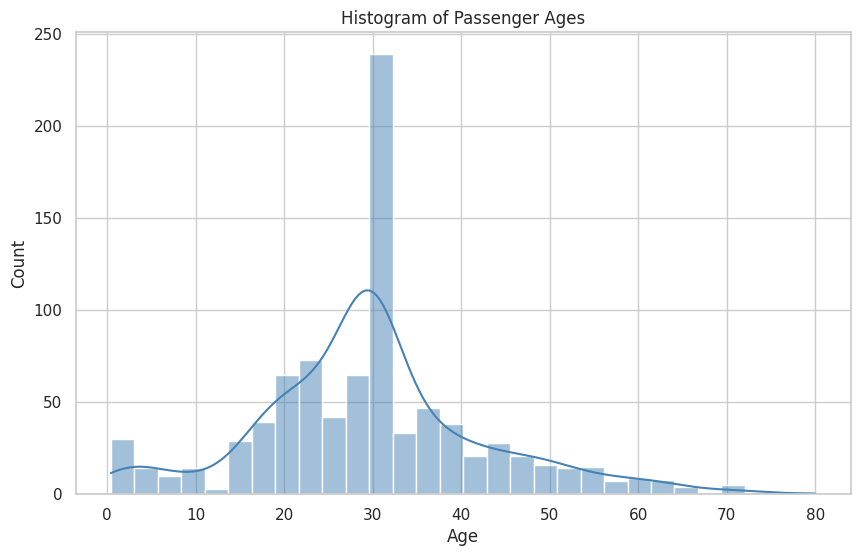

In [ ]:

# Histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


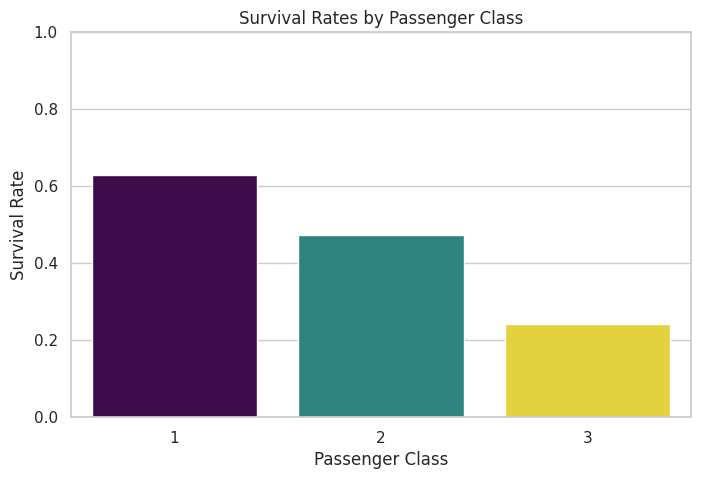

In [ ]:

# Bar plot of survival rates by passenger class
survival_by_pclass = df.groupby("Pclass")["Survived"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=survival_by_pclass, x="Pclass", y="Survived", hue="Pclass", palette="viridis", legend=False)
plt.title("Survival Rates by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


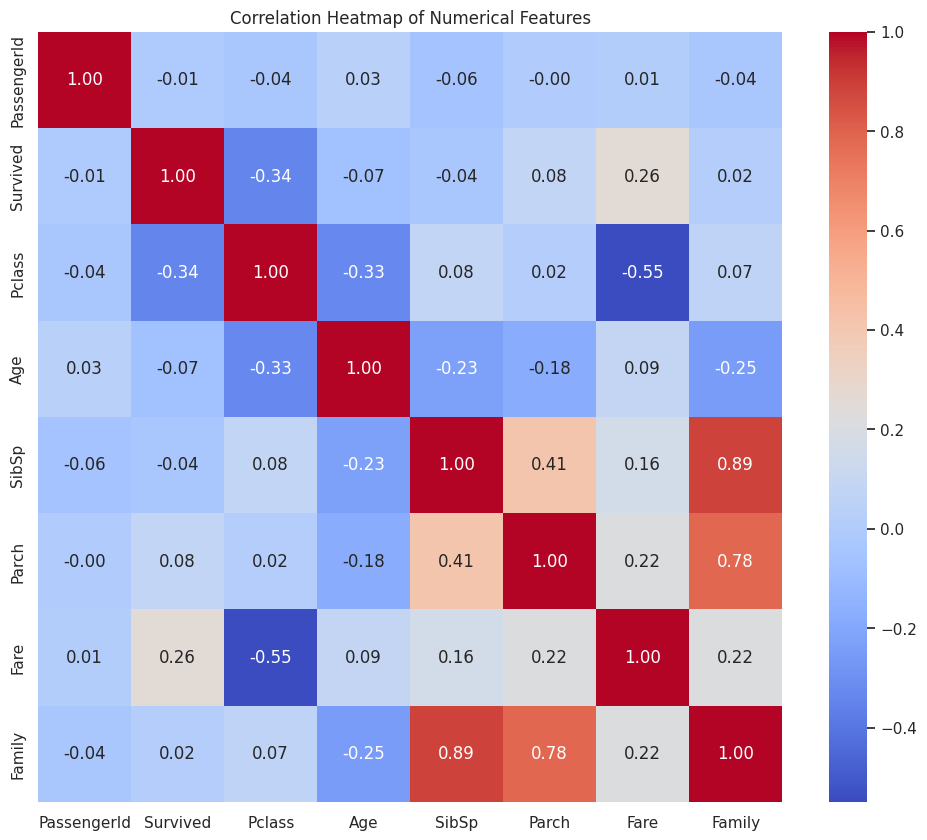

In [ ]:

# Heatmap of correlations between numerical features
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


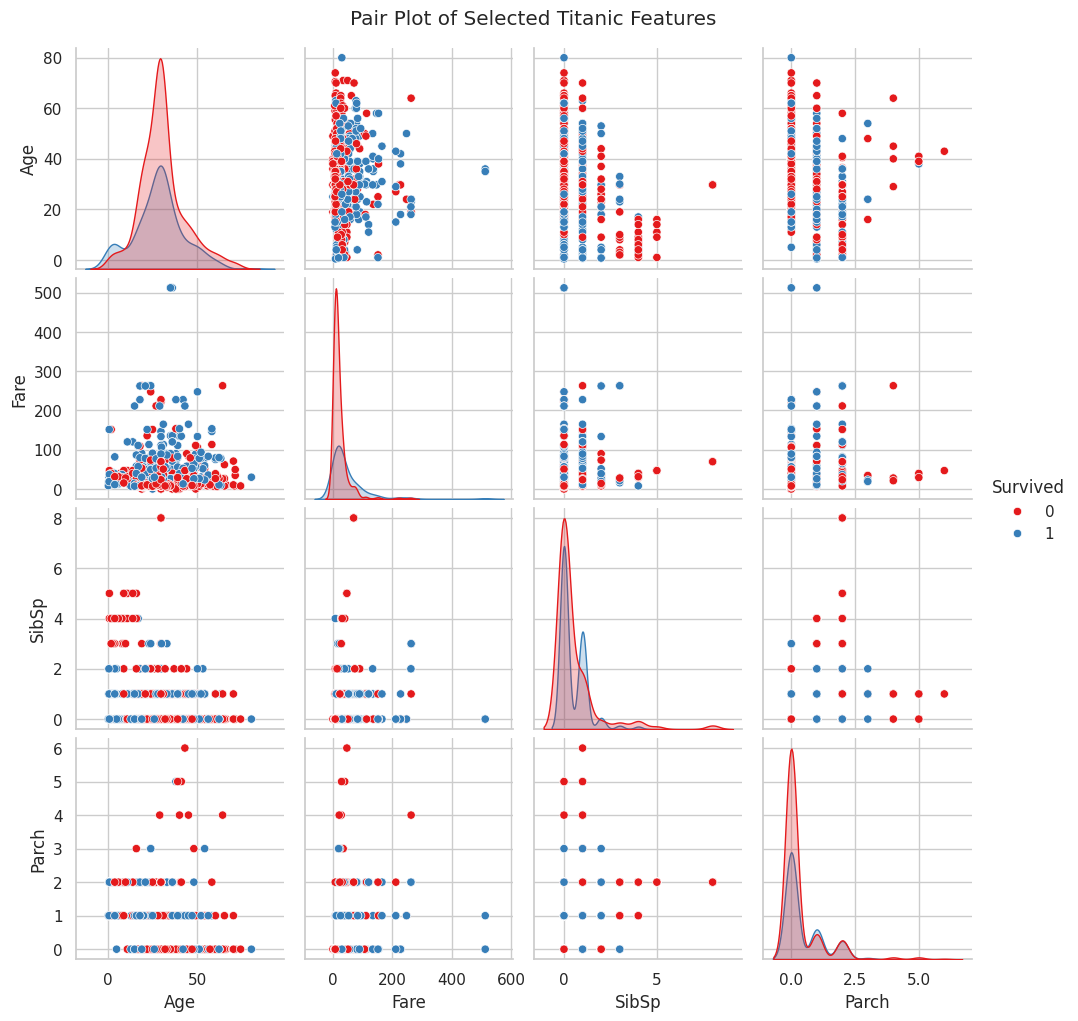

In [ ]:

# Pair plot of selected features colored by survival status
pair_data = df[["Age", "Fare", "SibSp", "Parch", "Survived"]].copy()

sns.pairplot(pair_data, hue="Survived", palette="Set1")
plt.suptitle("Pair Plot of Selected Titanic Features", y=1.02)
plt.show()



### Insight
The visualizations show that passenger age and fare vary widely. Survival rates differ across passenger classes, and Fare has some relationship with passenger class and survival.


## Task 8: Analyze Survival Rates

In [ ]:

# Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()

print("Survival rates by sex:")
print(survival_by_sex)

# Survival rate by passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean()

print("\nSurvival rates by passenger class:")
print(survival_by_class)


Survival rates by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rates by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64



### Insight
Female passengers had a higher survival rate than male passengers. First-class passengers also had a higher survival rate than passengers in lower classes.


## Task 9: Analyze Age Distribution

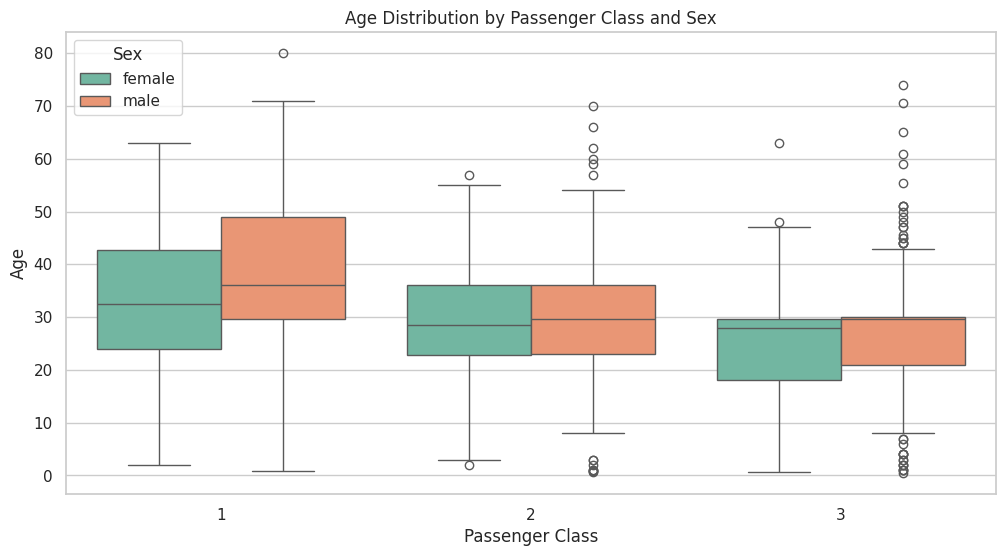

In [ ]:

# Box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex", palette="Set2")
plt.title("Age Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()



### Insight
The box plot compares the median, spread, and outliers in passenger age across passenger classes and sex.


## Task 10: Analyze Fare Distribution

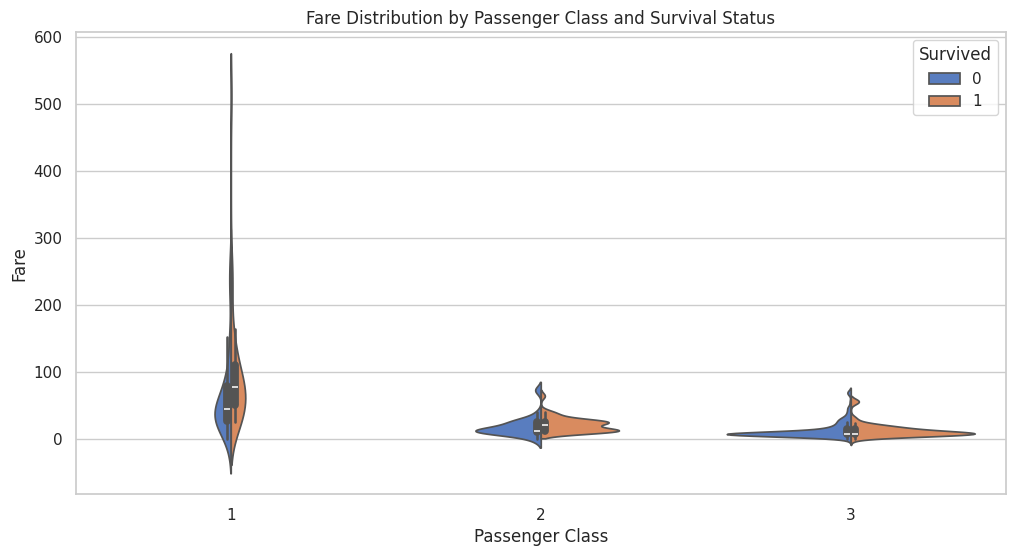

In [ ]:

# Violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="Pclass", y="Fare", hue="Survived", split=True, palette="muted")
plt.title("Fare Distribution by Passenger Class and Survival Status")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()



### Insight
Fares are generally higher in first class and lower in third class. The distribution also shows differences in fare levels between survivors and non-survivors.



## Conclusion

The Titanic EDA showed clear differences in survival by sex and passenger class. Data cleaning was necessary because the Age column contained missing values. New features such as passenger class category, cabin category, and family size helped make the dataset easier to analyze.


In [ ]:

print("EDA tasks completed.")


EDA tasks completed.
